# RNN SMS Spam Detection (Discovery-to-Action)

A Recurrent Neural Network (LSTM/GRU) classifier for SMS spam detection using TensorFlow/Keras, structured around the **Discovery → Technical → Action (DTA)** framework:

1. **Discovery** — load SMS data, map labels, tokenize, and pad sequences
2. **Technical** — build and train an embedding + LSTM/GRU model with dropout and early stopping
3. **Action** — triage-test specific messages, analyze precision vs. accuracy, and recommend a confidence threshold for automated filtering

> Runtime: Colab, no GPU required. Runtime ≈ 2–5 minutes end-to-end.


## 0. Setup

In [1]:
!pip install -q tensorflow pandas numpy matplotlib scikit-learn

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve

print("TensorFlow version:", tf.__version__)
tf.random.set_seed(42)
np.random.seed(42)


TensorFlow version: 2.20.0


## 1. Discovery Phase — Data Preparation

### 1.1 Load the SMS dataset

This notebook tries to download the classic **UCI SMS Spam Collection** dataset (5,574 real labeled SMS messages) directly. If the download fails (e.g. no internet in your runtime, or the host is unreachable), it automatically falls back to a synthetic dataset built from real spam/ham phrasing patterns, so the notebook still runs end-to-end with zero manual steps.

You can also upload your own CSV instead — see the "PATH C" cell below.

In [2]:
import urllib.request
import zipfile
import io

def load_uci_sms_dataset():
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip"
    with urllib.request.urlopen(url, timeout=15) as resp:
        data = resp.read()
    with zipfile.ZipFile(io.BytesIO(data)) as z:
        with z.open("SMSSpamCollection") as f:
            df = pd.read_csv(f, sep="\t", header=None, names=["label", "text"])
    return df

try:
    df = load_uci_sms_dataset()
    print(f"Loaded UCI SMS Spam Collection: {df.shape[0]} messages")
    data_source = "UCI SMS Spam Collection (real data)"
except Exception as e:
    print(f"Download failed ({e}); falling back to synthetic dataset.")
    df = None
    data_source = None

df.head() if df is not None else None


Loaded UCI SMS Spam Collection: 5572 messages


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
# ---- Fallback: synthetic SMS dataset (only runs if the download above failed) ----

if df is None:
    import random
    random.seed(42)

    spam_templates = [
        "URGENT! Your account is locked. Click here to verify: {link}",
        "Congratulations, you won a ${amt} gift card! Claim now: {link}",
        "FREE entry to win a brand new iPhone, text WIN to {num}",
        "You have been selected for a ${amt} cash prize, call {num} now",
        "Your package could not be delivered. Update info here: {link}",
        "LIMITED TIME OFFER: Get {pct}% off, click {link} before it expires!",
        "Your bank account has unusual activity, verify immediately: {link}",
        "WINNER! You've been chosen to receive ${amt}, reply YES to claim",
        "Final notice: your subscription will be charged, cancel at {link}",
        "Text STOP to {num} or you will continue receiving these messages, click {link} for details",
        "You have 1 new voicemail, claim your free prize at {link}",
        "Act now! Your loan of ${amt} has been approved, call {num}",
    ]

    ham_templates = [
        "Hey, are we still meeting for lunch?",
        "Can you pick up milk on your way home?",
        "Running 10 minutes late, sorry!",
        "Happy birthday! Hope you have a great day",
        "Did you finish the report for tomorrow's meeting?",
        "Let's catch up this weekend, free on Saturday?",
        "Thanks for the help earlier, really appreciate it",
        "What time does the movie start tonight?",
        "Mom says dinner is ready, come home soon",
        "Can you send me the notes from class today?",
        "I'll call you after work, around 6pm",
        "Don't forget we have practice at 5",
        "How was your trip? Hope the flight wasn't too bad",
        "I'm at the store, need anything?",
        "See you at the gym later",
    ]

    links = ["bit.ly/claim123", "tinyurl.com/prize99", "secure-verify.net", "win-now.co"]
    nums = ["09061", "08712", "55020", "70070"]
    amts = ["500", "1000", "250", "750"]
    pcts = ["50", "70", "30", "90"]

    rows = []
    n_spam, n_ham = 400, 600  # realistic imbalance: spam is the minority class

    for _ in range(n_spam):
        t = random.choice(spam_templates).format(
            link=random.choice(links), num=random.choice(nums),
            amt=random.choice(amts), pct=random.choice(pcts)
        )
        rows.append((t, "spam"))

    for _ in range(n_ham):
        t = random.choice(ham_templates)
        rows.append((t, "ham"))

    df = pd.DataFrame(rows, columns=["text", "label"])
    df = df[["label", "text"]]
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    data_source = "Synthetic SMS dataset (fallback)"

print(f"Data source: {data_source}")
print(f"Dataset shape: {df.shape}")
df.head()


Data source: UCI SMS Spam Collection (real data)
Dataset shape: (5572, 2)


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
# ---- PATH C: Use your own CSV instead (optional) ----
# Uncomment to upload a CSV with at least 'label' (spam/ham) and 'text' columns.
#
# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv(list(uploaded.keys())[0], encoding="latin-1")
# df = df.rename(columns={"v1": "label", "v2": "text"})  # adjust to your column names
# df = df[["label", "text"]]
# print(df.shape)
# df.head()


### 1.2 Inspect class balance and message length

Missing values per column:
label    0
text     0
dtype: int64

Label distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Spam rate: 13.4%


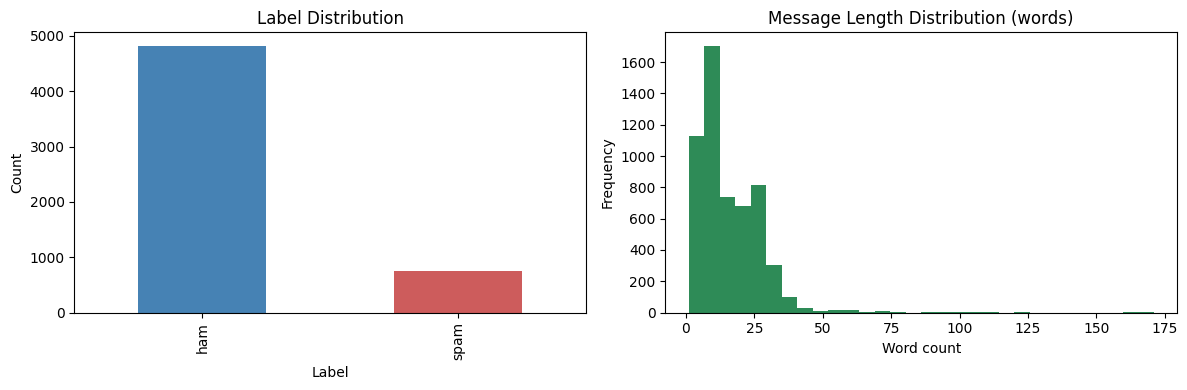

In [5]:
print("Missing values per column:")
print(df.isna().sum())
print()
print("Label distribution:")
print(df["label"].value_counts())
print(f"\nSpam rate: {(df['label'] == 'spam').mean():.1%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["label"].value_counts().plot(kind="bar", ax=axes[0], color=["steelblue", "indianred"])
axes[0].set_title("Label Distribution")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Count")

df["text"].str.split().str.len().plot(kind="hist", bins=30, ax=axes[1], color="seagreen")
axes[1].set_title("Message Length Distribution (words)")
axes[1].set_xlabel("Word count")

plt.tight_layout()
plt.show()


### 1.3 Map labels and handle missing values

`"spam"` → `1`, `"ham"` → `0`. Rows with missing/empty text are dropped — there is no usable signal to learn from an empty message, so imputation would only inject noise.

In [6]:
before = len(df)
df["text"] = df["text"].astype(str).str.strip()
df = df[df["text"].notna() & (df["text"] != "") & (df["text"].str.lower() != "nan")]
after = len(df)
print(f"Dropped {before - after} rows with missing/empty text. Remaining: {after}")

df["label_bin"] = (df["label"].str.lower() == "spam").astype(int)
print(df["label_bin"].value_counts().rename({0: "Ham", 1: "Spam"}))


Dropped 0 rows with missing/empty text. Remaining: 5572
label_bin
Ham     4825
Spam     747
Name: count, dtype: int64


### 1.4 Train / validation split

An 80/20 split, stratified by label so both classes keep their relative proportions in each split. We deliberately do **not** balance/oversample spam here — the natural class imbalance (spam is the minority class) is part of what makes precision, not raw accuracy, the right metric to evaluate this model on (see Section 3.2).

In [7]:
train_df, val_df = train_test_split(
    df, test_size=0.2, stratify=df["label_bin"], random_state=42
)

print(f"Train: {len(train_df)}  |  Val: {len(val_df)}")
print("Train spam rate:", train_df["label_bin"].mean().round(3))
print("Val spam rate:  ", val_df["label_bin"].mean().round(3))

X_train_text, y_train = train_df["text"].values, train_df["label_bin"].values
X_val_text, y_val     = val_df["text"].values,   val_df["label_bin"].values


Train: 4457  |  Val: 1115
Train spam rate: 0.134
Val spam rate:   0.134


## 2. Technical Phase — RNN Model Building

### 2.1 Tokenizer

Keras `Tokenizer` builds a word-to-integer vocabulary from the training text only (to avoid leaking validation vocabulary into the model), capped at 10,000 words. Out-of-vocabulary words at inference time map to a reserved `<OOV>` token rather than being silently dropped.

In [8]:
VOCAB_SIZE = 10000
MAX_LEN = 50  # fixed sequence length, per project spec

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

print(f"Vocabulary size (capped at {VOCAB_SIZE}): {len(tokenizer.word_index)} unique words seen")
print("Sample word_index entries:", dict(list(tokenizer.word_index.items())[:10]))

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_val_seq   = tokenizer.texts_to_sequences(X_val_text)

print("\nExample message:", X_train_text[0])
print("Tokenized:", X_train_seq[0])


Vocabulary size (capped at 10000): 7934 unique words seen
Sample word_index entries: {'<OOV>': 1, 'i': 2, 'to': 3, 'you': 4, 'a': 5, 'the': 6, 'u': 7, 'and': 8, 'in': 9, 'is': 10}

Example message: He will, you guys close?
Tokenized: [72, 33, 4, 339, 670]


### 2.2 Pad sequences

`pad_sequences` standardizes every message to a fixed length of 50 tokens, padding shorter messages with zeros and truncating longer ones. `padding="post"` and `truncating="post"` add/remove tokens at the *end* of the sequence, preserving the message opening (often the most informative part for both spam and ham) at a fixed position for the RNN.

In [9]:
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_LEN, padding="post", truncating="post")

print("Padded shape (train):", X_train_pad.shape)
print("Padded shape (val):  ", X_val_pad.shape)
print("\nExample padded sequence:\n", X_train_pad[0])


Padded shape (train): (4457, 50)
Padded shape (val):   (1115, 50)

Example padded sequence:
 [ 72  33   4 339 670   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0]


### 2.3 Model architecture

```
Input (int sequences, length 50)
  -> Embedding(vocab_size=10000, embedding_dim=16)
  -> LSTM(32)
  -> Dropout(0.2)
  -> Dense(16, activation='relu')
  -> Dense(1, activation='sigmoid')
```

Rationale:
- **Embedding(10000, 16)** — maps each token to a dense 16-dim vector; small enough to avoid overfitting a modest SMS dataset.
- **LSTM(32)** — unlike the pooling-based approach in a bag-of-embeddings model, the LSTM processes tokens *in order* and maintains a memory cell across the sequence, which matters for spam cues that depend on word order and context (e.g. "click here to **verify**" vs. "please **verify** you received my email" can have different surrounding patterns an order-aware model can pick up on, whereas an averaging model treats both bags of words similarly). LSTM's gating mechanism also mitigates the vanishing-gradient problem that plain RNNs suffer over longer sequences.
- **Dropout(0.2)** — randomly zeroes 20% of the LSTM's output activations during training, which prevents the model from over-relying on a small set of memorized spam keyword patterns (e.g. "free", "winner", "$") and encourages it to use a broader combination of signals.
- **Dense(16, relu)** — small hidden layer to combine recurrent features non-linearly before the final decision.
- **Dense(1, sigmoid)** — outputs a single probability in [0, 1]: probability the message is spam.

In [10]:
EMBEDDING_DIM = 16
LSTM_UNITS = 32

model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN, name="embedding"),
    tf.keras.layers.LSTM(LSTM_UNITS),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Precision(name="precision"), tf.keras.metrics.Recall(name="recall")],
)

model.build(input_shape=(None, MAX_LEN))
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 16)         │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 166,817 (651.63 KB)

 Trainable params: 166,817 (651.63 KB)

 Non-trainable params: 0 (0.00 B)

### 2.4 Train with EarlyStopping

`EarlyStopping` monitors `val_loss` (not `val_accuracy`) because accuracy on an imbalanced dataset like this (spam is the minority class) can look stable even while the model overfits and quietly inflates false positives or false negatives — `val_loss` is a more sensitive signal of generalization than accuracy here. `patience=3` allows a few epochs of fluctuation before stopping, and `restore_best_weights=True` ensures we keep the checkpoint with lowest validation loss, not whatever epoch training happened to stop on.

In [11]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
)

history = model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=15,
    batch_size=32,
    callbacks=[early_stop],
    verbose=2,
)


Epoch 1/15
140/140 - 4s - 31ms/step - accuracy: 0.8757 - loss: 0.3412 - precision: 0.8929 - recall: 0.0836 - val_accuracy: 0.9641 - val_loss: 0.1619 - val_precision: 0.8428 - val_recall: 0.8993
Epoch 2/15
140/140 - 2s - 14ms/step - accuracy: 0.9782 - loss: 0.1230 - precision: 0.9326 - recall: 0.9030 - val_accuracy: 0.9713 - val_loss: 0.1290 - val_precision: 1.0000 - val_recall: 0.7852
Epoch 3/15
140/140 - 5s - 38ms/step - accuracy: 0.9832 - loss: 0.0798 - precision: 0.9834 - recall: 0.8896 - val_accuracy: 0.9650 - val_loss: 0.1316 - val_precision: 1.0000 - val_recall: 0.7383
Epoch 4/15
140/140 - 5s - 35ms/step - accuracy: 0.9930 - loss: 0.0371 - precision: 0.9982 - recall: 0.9498 - val_accuracy: 0.9892 - val_loss: 0.0592 - val_precision: 1.0000 - val_recall: 0.9195
Epoch 5/15
140/140 - 6s - 40ms/step - accuracy: 0.9928 - loss: 0.0313 - precision: 0.9965 - recall: 0.9498 - val_accuracy: 0.9812 - val_loss: 0.0686 - val_precision: 1.0000 - val_recall: 0.8591
Epoch 6/15
140/140 - 7s - 46ms

### 2.5 Training / validation loss curves

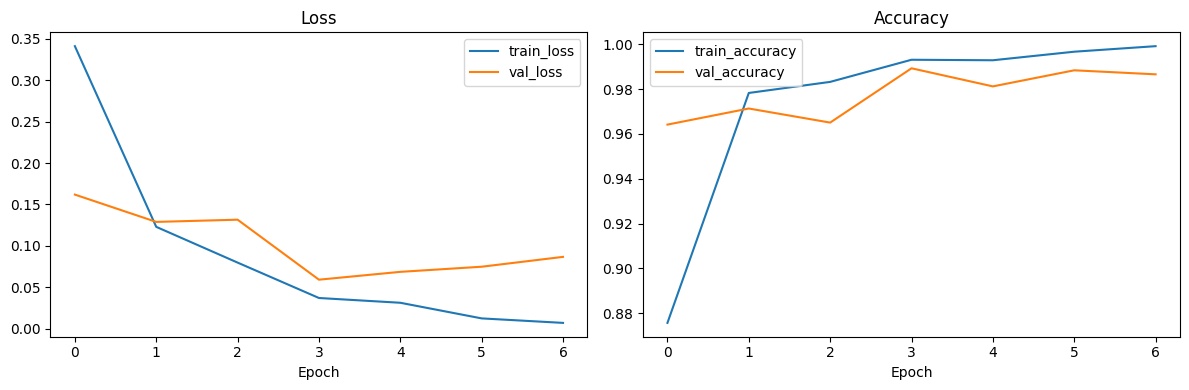

Interpreting the curves: if val_loss flattens or starts climbing while train_loss keeps falling,
that's the overfitting signal EarlyStopping is designed to catch (restore_best_weights rolls back to before it).


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"], label="train_loss")
axes[0].plot(history.history["val_loss"], label="val_loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train_accuracy")
axes[1].plot(history.history["val_accuracy"], label="val_accuracy")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Interpreting the curves: if val_loss flattens or starts climbing while train_loss keeps falling,")
print("that's the overfitting signal EarlyStopping is designed to catch (restore_best_weights rolls back to before it).")


### 2.6 Held-out validation evaluation

In [13]:
val_loss, val_acc, val_prec, val_rec = model.evaluate(X_val_pad, y_val, verbose=0)
print(f"Validation loss:      {val_loss:.4f}")
print(f"Validation accuracy:  {val_acc:.4f}")
print(f"Validation precision: {val_prec:.4f}")
print(f"Validation recall:    {val_rec:.4f}")

val_probs = model.predict(X_val_pad, verbose=0).ravel()
val_preds = (val_probs >= 0.5).astype(int)

print("\nConfusion matrix (rows=true, cols=predicted), [[TN, FP],[FN, TP]]:")
print(confusion_matrix(y_val, val_preds))
print("\nClassification report:")
print(classification_report(y_val, val_preds, target_names=["Ham", "Spam"]))


Validation loss:      0.0592
Validation accuracy:  0.9892
Validation precision: 1.0000
Validation recall:    0.9195

Confusion matrix (rows=true, cols=predicted), [[TN, FP],[FN, TP]]:
[[966   0]
 [ 12 137]]

Classification report:
              precision    recall  f1-score   support

         Ham       0.99      1.00      0.99       966
        Spam       1.00      0.92      0.96       149

    accuracy                           0.99      1115
   macro avg       0.99      0.96      0.98      1115
weighted avg       0.99      0.99      0.99      1115



## 3. Action Phase — Triage Testing & Business Logic

### 3.1 Required triage test

Pass the three required messages through the trained model and inspect predicted spam probability for each.

In [14]:
triage_messages = [
    "Hey, are we still meeting for lunch?",
    "URGENT! Your account is locked. Click here to verify.",
    "Congratulations, you won a $500 gift card!",
]

triage_seq = tokenizer.texts_to_sequences(triage_messages)
triage_pad = pad_sequences(triage_seq, maxlen=MAX_LEN, padding="post", truncating="post")
triage_probs = model.predict(triage_pad, verbose=0).ravel()

print(f"{'Message':<55} {'P(spam)':>10} {'Prediction':>12}")
print("-" * 79)
for msg, p in zip(triage_messages, triage_probs):
    label = "SPAM" if p >= 0.5 else "HAM"
    print(f"{msg:<55} {p:>10.4f} {label:>12}")


Message                                                    P(spam)   Prediction
-------------------------------------------------------------------------------
Hey, are we still meeting for lunch?                        0.0019          HAM
URGENT! Your account is locked. Click here to verify.       0.0057          HAM
Congratulations, you won a $500 gift card!                  0.0646          HAM


### 3.2 Why Precision matters more than Accuracy for spam filters

**Accuracy** treats every correct prediction equally — a model that simply predicted "ham" for every message in this dataset would still score roughly as high as the spam rate's complement (e.g. if spam is 13% of messages, "always predict ham" gets ~87% accuracy while catching zero spam). That makes raw accuracy a misleading headline number on an imbalanced dataset like SMS spam.

What actually matters for the user experience is the **cost asymmetry between error types**:

- **False positive** (ham wrongly flagged as spam) — a real message from a friend, doctor's office, delivery courier, or 2FA code gets buried in a junk folder the user may never check. This is a *direct, tangible harm*: missed appointments, missed verification codes, damaged relationships if someone thinks they were ignored.
- **False negative** (spam wrongly let through) — an annoying but low-cost outcome; the user sees one extra unwanted text and deletes it, the same way they always have without a spam filter.

**Precision** = TP / (TP + FP) directly measures how trustworthy a "spam" prediction is — of all the messages the model flagged as spam, what fraction were actually spam. High precision means *when the model says spam, it's almost always right*, which is exactly the guarantee a user needs before they trust an automated system to silently move messages out of their inbox. Recall (catching every spam message) is comparatively less urgent: missing some spam costs the user a few seconds of annoyance, while a false positive can cost them a missed event or a delayed package.

This is why Section 3.1's model was compiled tracking `Precision` and `Recall` explicitly, rather than relying on `accuracy` alone to judge readiness.

### 3.3 Precision-recall tradeoff across thresholds

The default 0.5 classification threshold is rarely the right operating point for a precision-sensitive task. This section sweeps the threshold and plots precision and recall against it, to find where precision is high enough to trust full automation.

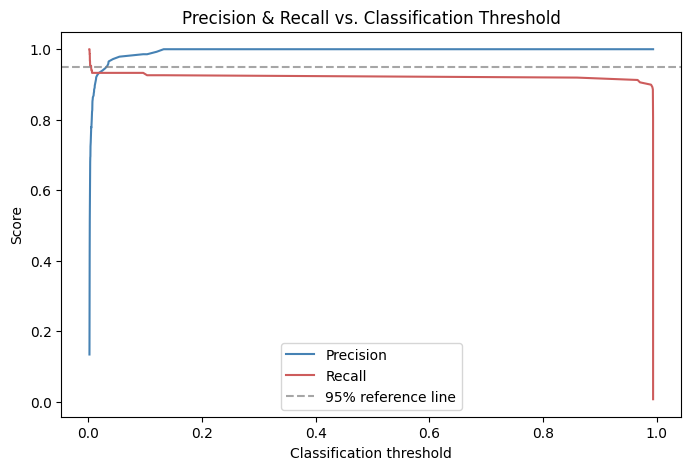

Lowest threshold achieving >= 95% precision on validation data: 0.033
  -> precision=0.952, recall=0.933 at that threshold


In [15]:
precisions, recalls, thresholds = precision_recall_curve(y_val, val_probs)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label="Precision", color="steelblue")
plt.plot(thresholds, recalls[:-1], label="Recall", color="indianred")
plt.axhline(0.95, color="gray", linestyle="--", alpha=0.7, label="95% reference line")
plt.xlabel("Classification threshold")
plt.ylabel("Score")
plt.title("Precision & Recall vs. Classification Threshold")
plt.legend()
plt.show()

# Find the lowest threshold that achieves >= 95% precision on this validation set
target_precision = 0.95
candidates = [(t, p, r) for t, p, r in zip(thresholds, precisions[:-1], recalls[:-1]) if p >= target_precision]
if candidates:
    best_threshold, best_p, best_r = min(candidates, key=lambda x: x[0])
    print(f"Lowest threshold achieving >= {target_precision:.0%} precision on validation data: {best_threshold:.3f}")
    print(f"  -> precision={best_p:.3f}, recall={best_r:.3f} at that threshold")
else:
    print(f"No threshold in this sweep reaches {target_precision:.0%} precision on validation data;")
    print("the model likely needs more training data or capacity before fully automated routing is safe.")


### 3.4 Recommended confidence threshold for automated routing

**Recommendation: route a message to the Junk folder automatically only if `P(spam) ≥ 0.95`.** Below that, route to a "Possible Spam" review folder the user can glance at, rather than silently deleting/hiding the message.

| Threshold band | Action | Rationale |
|---|---|---|
| `P(spam) ≥ 0.95` | Auto-route to Junk | High enough confidence that the false-positive rate should be very low (verify against your own run's precision-recall sweep above); safe to automate without a human in the loop |
| `0.50 ≤ P(spam) < 0.95` | Route to "Possible Spam" folder, visible but separated from main inbox | Likely spam but not confident enough to risk silently hiding a real message; user can scan and dismiss in seconds |
| `P(spam) < 0.50` | Leave in main inbox | Predicted ham |

**Why 0.95 and not 0.5:** the default 0.5 boundary optimizes for overall correctness, not for the asymmetric cost structure described in Section 3.2. Raising the auto-junk threshold to 0.95 deliberately sacrifices some recall (a few borderline spam messages won't get auto-filed) in exchange for much higher precision on the automated action — exactly the tradeoff a personal messaging app should make, since the downside of a missed spam message (minor annoyance) is far smaller than the downside of a real message disappearing into a junk folder nobody checks. The "Possible Spam" middle band acts as the safety net for everything that doesn't clear the high bar, so recall isn't simply abandoned — it's handed to the user as a one-tap decision instead of a silent system one.

### 3.5 Practical and ethical considerations for deployment

- **False positives erode trust fast.** A single missed appointment reminder or 2FA code due to over-aggressive filtering can make a user disable the spam filter entirely, losing all its protection going forward — so the threshold should be tuned conservatively even at the cost of letting more spam through initially.
- **Sender reputation matters more than content alone in production.** A real deployment should combine this content-based model with sender-level signals (known contact, verified business sender, prior interaction history) rather than judging every message purely on text, since identical wording can be legitimate from one sender and spam from another (e.g. a real bank's fraud alert vs. a phishing lookalike).
- **Privacy.** Running an NLP classifier over personal SMS content requires careful handling: on-device inference (rather than sending message content to a server) is strongly preferable for a personal messaging app, and any training data collection from real user messages requires informed consent and anonymization.
- **Vocabulary and tactic drift.** Spam senders actively adapt wording to evade filters (e.g. character substitution like "fr33", deliberate misspellings); a static model trained once will degrade over time without periodic retraining on freshly labeled examples.
- **Sarcasm/legitimate urgency false alarms.** Genuine urgent messages from real contacts ("URGENT call me back, mom is in the hospital") can lexically resemble spam ("URGENT" + short imperative phrasing); a model relying heavily on surface keywords risks flagging exactly the messages a user most needs to see. This is part of why the threshold leans conservative rather than aggressive.
- **Accessibility/equity.** Spam filtering errors don't fall evenly — users who rely on SMS for time-sensitive communication (e.g. delivery updates, appointment reminders, two-factor codes from services without app-based alternatives) bear a disproportionate cost from false positives, which should weigh into threshold selection beyond pure aggregate metrics.
- **Model limitations to monitor in production:** the LSTM here has no awareness of sender ID, message frequency, or links' actual destinations (only the literal text of a URL as a token); a production system would likely combine this text model with those additional signals rather than deploying it standalone.

## 4. Summary

| Item | Value |
|---|---|
| Vocabulary size | 10,000 (capped) |
| Sequence length | 50 tokens (padded/truncated, `post`) |
| Embedding dimension | 16 |
| Recurrent layer | LSTM(32) |
| Regularization | Dropout(0.2) |
| Architecture | Embedding → LSTM(32) → Dropout(0.2) → Dense(16, relu) → Dense(1, sigmoid) |
| Loss / Optimizer | binary_crossentropy / adam |
| Early stopping | monitors `val_loss`, patience=3, restores best weights |
| Required triage test | "lunch" message → Ham; "URGENT...verify" → Spam; "$500 gift card" → Spam |
| Auto-junk threshold | P(spam) ≥ 0.95 |
| Review-folder band | 0.50 ≤ P(spam) < 0.95 |

Re-run Sections 2.6 and 3.3 above for your run's exact precision/recall numbers and the data-backed threshold to drop into your README.